In [2]:
# this walk-through was adapted from the following two tutorials, check them out for more info:
# https://machinelearningmastery.com/machine-learning-in-python-step-by-step/
# https://towardsdatascience.com/exploring-classifiers-with-python-scikit-learn-iris-dataset-2bcb490d2e1b


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Import and examine data

In [10]:
iris = pd.read_csv("/home/sam/notes/compSci/2611/wk5/iris.csv")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
iris.shape

(150, 5)

In [12]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [13]:
iris["class"].value_counts()

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

# Data formatting

In [14]:
train, test = train_test_split(iris, test_size = .3, stratify = iris['class'], random_state = 0)
# splits the data into a training and testing set
# test_size = .3 makes the test set 30% of the data
# stratify = iris['class'] makes the classes equally represented in the training/testing sets
# setting a random state ensures that the data will be divided the same way each time

In [15]:
train["class"].value_counts()
# in fact we do have balanced training/testing classes

class
Iris-virginica     35
Iris-setosa        35
Iris-versicolor    35
Name: count, dtype: int64

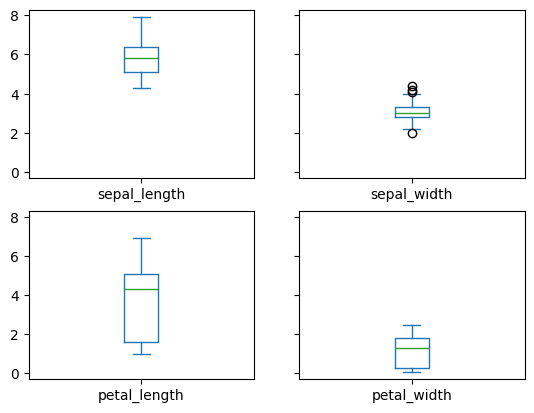

In [16]:
# lets visualize the training set
train.plot(kind = "box", subplots = True, layout = (2,2), sharey = True)
plt.show()

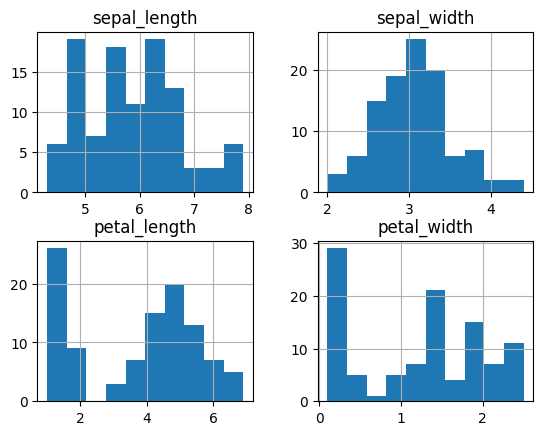

In [17]:
train.hist()
plt.show()

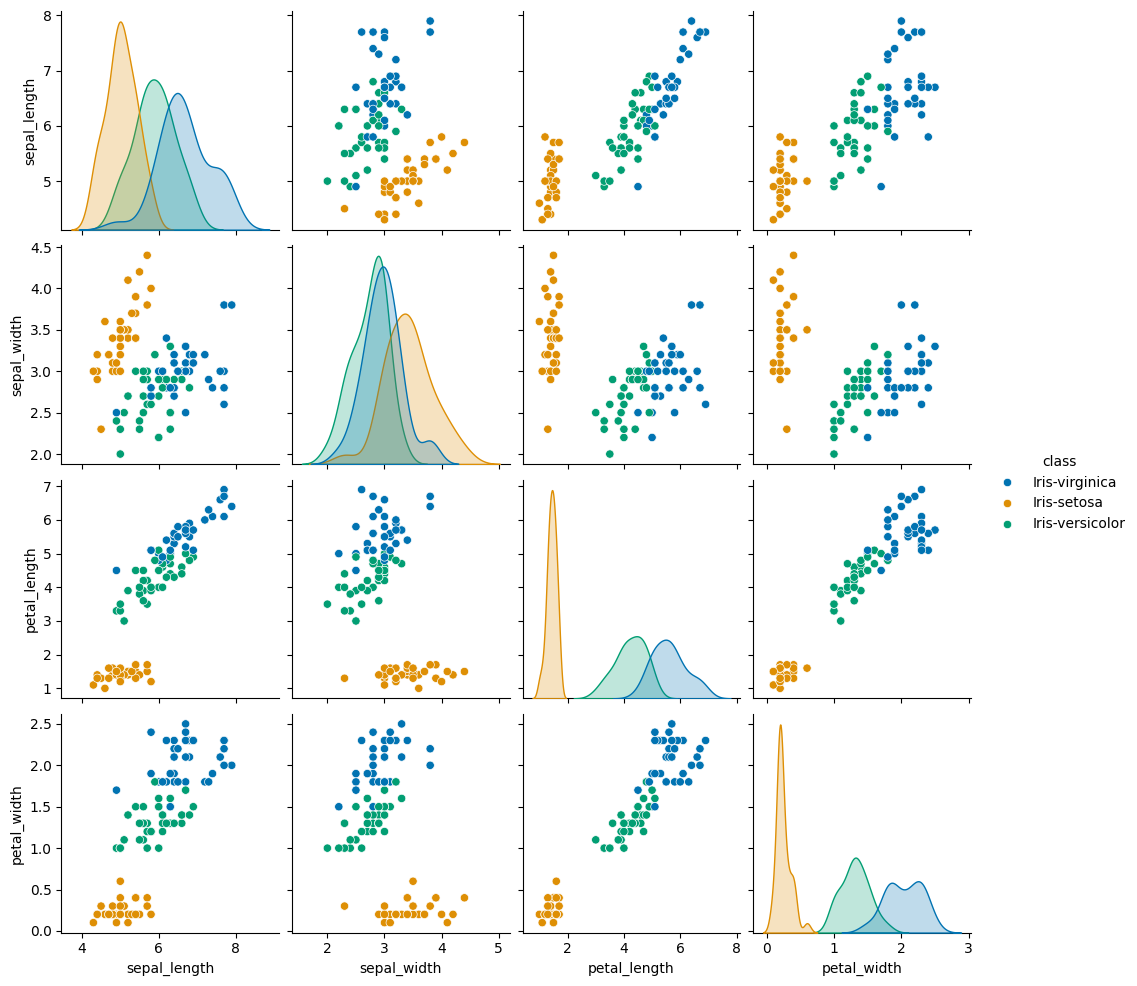

In [18]:
sns.pairplot(train, hue="class", palette = 'colorblind')
plt.show()

# Build a model

In [19]:
# split yourdata sets into predictive attributs (x)
# and the class you are trying to predict (y)

x_train = train[['sepal_length','sepal_width', 'petal_length', 'petal_width']]
y_train = train['class']

x_test = test[['sepal_length','sepal_width', 'petal_length', 'petal_width']]
y_test = test['class']

#first model we will try is a decision tree
mod_dt = DecisionTreeClassifier(max_depth = 3,random_state = 1) #declare model "estimator"
mod_dt.fit(x_train,y_train) #fit the model to your data
y_pred=mod_dt.predict(x_test) #use your "fitted" model to predict labels for the test data
print(y_pred)

['Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica']


In [20]:
# how good was the model at predicting?
metrics.accuracy_score(y_pred,y_test)

0.9555555555555556

In [21]:
mod_dt.feature_importances_

array([0.0093633 , 0.        , 0.02431926, 0.96631744])

In [22]:
print(mod_dt.classes_)
print(x_train.columns)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')


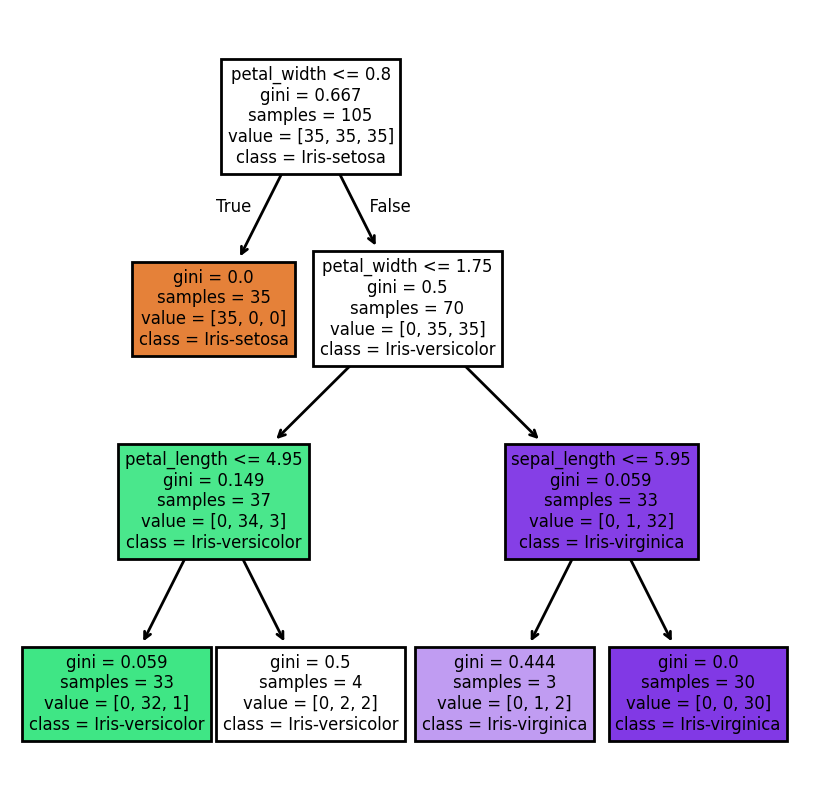

In [23]:
#lets visualize the tree
plt.figure(figsize = (5,5), dpi = 200)
plot_tree(mod_dt,feature_names=x_train.columns,class_names=mod_dt.classes_, filled = True)
plt.show()

In [24]:
#lets look at precision, recall, and F1
print(metrics.classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      1.00      0.94        15
 Iris-virginica       1.00      0.87      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



# Lets try a different model
Naive Bayes!

In [25]:
mod_nb = GaussianNB()
mod_nb.fit(x_train,y_train) #fit the model to your data
y_pred2=mod_nb.predict(x_test) #use your "fitted" model to predict labels for the test data
# how good was the model at predicting?
metrics.accuracy_score(y_pred2,y_test)

0.9777777777777777

In [26]:
#refit the model with just the petal attributes

mod_nb.fit(x_train[["petal_length", "petal_width"]], y_train)
y_pred3 = mod_nb.predict(x_test[["petal_length", "petal_width"]])
print("accuracy: ", metrics.accuracy_score(y_pred3,y_test))
#lets look at precision, recall, and F1
print(metrics.classification_report(y_test, y_pred3))

accuracy:  1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      1.00      1.00        15
 Iris-virginica       1.00      1.00      1.00        15

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



The model does **better** using only two features. This implies that the model may be "overfitting" when using all 4 features

# What if we randomly got a bad "split" of the data into training and testing sets?
There are solutions to this problem, one of the most common is called **k-fold cross validation**. K-fold cross validation divides your data into k smaller data sets, then trains the model on k different subsets of the data.

Lets test out a few different models using k-fold cross validation

In [27]:
# Different models to test
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('KNN', KNeighborsClassifier()))
models.append(('DT', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))
# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=5, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, x_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(name, round(cv_results.mean(),3), round(cv_results.std(),3))

LR 0.952 0.052
KNN 0.933 0.038
DT 0.924 0.065
NB 0.952 0.03
SVM 0.943 0.047


/home/sam/notes/compSci/2611/daVenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/sam/notes/compSci/2611/daVenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/sam/notes/compSci/2611/daVenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoi

/tmp/ipykernel_177725/3731319058.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names)


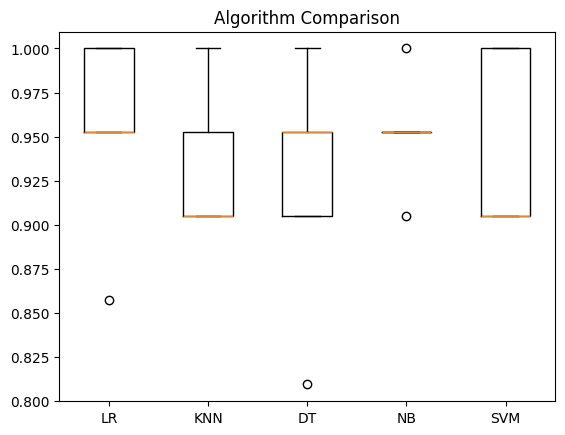

In [28]:
plt.boxplot(results, labels=names)
plt.title('Algorithm Comparison')
plt.show()

# Your turn: build a model to predict basketball games!
Download the basketballData.csv file from Canvas. Choose what features (columns) you think are most predictive and choose a model from above and try to build the best model you can! Remember, the basic format for modeling in python is:

1) divide your data into a training and testing set

2) declare a model esitmator

3) "fit" the model

4) evaluate the model

For information about what each column means, see: https://www.sports-reference.com/cbb/seasons/2021-school-stats.html

The first step has already been done for you below. The column you are interested in predicting is 'Team1Win?'. Don't worry about trying to do k-fold cross validation. Just choose parameters and try it out!

In [4]:
basketballData = pd.read_csv("/home/sam/notes/compSci/2611/wk5/basketballData.csv")
pd.set_option("display.max.columns", None)

basketballData.head()

# list the columns
basketballData.columns

Index(['Unnamed: 0', 'Year', 'Team1', 'Team2', 'Team1Win?', 'Team1Wins',
       'Team1SRS', 'Team1ORtg', 'Team1TS%', 'Team1eFG%', 'Team1OppORtg',
       'Team1OppTS%', 'Team1OppeFG%', 'Team1Pace', 'Team1TRB%', 'Team1AST%',
       'Team1TOV%', 'Team1Steal%', 'Team1Block%', 'Team2Wins', 'Team2SRS',
       'Team2ORtg', 'Team2TS%', 'Team2eFG%', 'Team2OppORtg', 'Team2OppTS%',
       'Team2OppeFG%', 'Team2Pace', 'Team2TRB%', 'Team2AST%', 'Team2TOV%',
       'Team2Steal%', 'Team2Block%'],
      dtype='object')

In [ ]:
#divide into training and testing
train, test = train_test_split(basketballData, test_size = .2, stratify = basketballData['Team1Win?'], random_state = 0)

# Enhanced feature set with offensive, defensive, and tempo metrics
model_attributes = [
    # Core team strength metrics
    "Team1Wins", "Team1SRS", 
    "Team2Wins", "Team2SRS",
    
    # Offensive efficiency
    "Team1ORtg", "Team1TS%", "Team1eFG%",
    "Team2ORtg", "Team2TS%", "Team2eFG%",
    
    # Defensive efficiency (opponent ratings - lower is better)
    "Team1OppORtg", "Team2OppORtg",
    
    # Pace and style
    "Team1Pace", "Team2Pace",
    
    # Key performance metrics
    "Team1TRB%", "Team2TRB%",  # Rebounding
    "Team1TOV%", "Team2TOV%",  # Turnovers
    "Team1Steal%", "Team2Steal%"  # Steals
]

#divide into x and y
x_train = train[model_attributes]
y_train = train["Team1Win?"]

x_test = test[model_attributes]
y_test = test["Team1Win?"]

#build your model
mod_bball = LogisticRegression(solver='liblinear', multi_class='ovr') #feel free to swap this model for another one from above!
mod_bball.fit(x_train, y_train)
bball_pred = mod_bball.predict(x_test)
print("accuracy: ", metrics.accuracy_score(bball_pred,y_test))

Using 20 features for prediction
Features: ['Team1Wins', 'Team1SRS', 'Team2Wins', 'Team2SRS', 'Team1ORtg', 'Team1TS%', 'Team1eFG%', 'Team2ORtg', 'Team2TS%', 'Team2eFG%', 'Team1OppORtg', 'Team2OppORtg', 'Team1Pace', 'Team2Pace', 'Team1TRB%', 'Team2TRB%', 'Team1TOV%', 'Team2TOV%', 'Team1Steal%', 'Team2Steal%']


/home/sam/notes/compSci/2611/daVenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


accuracy:  0.7655462184873949
